<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/02_Bernstein_Vazirani/Bernstein_Vazirani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bernstein-Vazirani Algorithm Demonstration

This repository contains a Qiskit implementation of the Bernstein-Vazirani algorithm, demonstrating a clear case of quantum advantage over classical computing.

## The Problem

We are given a black-box function (an Oracle) that hides a secret binary string $s$ (for example, `101101`). Our goal is to find the secret string.

* **Classical approach:** A classical computer must query the Oracle to guess the string one bit at a time. For a string of $N$ bits, the classical complexity is $O(N)$ queries.
* **Quantum approach:** By utilizing superposition and phase kickback, a quantum computer can determine the entire hidden string in exactly $O(1)$ queries—meaning it only has to ask the Oracle a single time, regardless of how long the string is.

## The Math

To achieve this, we initialize our input qubits in the $|0\rangle$ state and an ancilla qubit in the $|1\rangle$ state. We apply Hadamard gates to all qubits to create an equal superposition:

$$|\psi\rangle = \frac{1}{\sqrt{2^n}}\sum_{x=0}^{2^n-1}|x\rangle \otimes |-\rangle$$

When we pass this superposition into the Oracle, it flips the phase of the states based on the bitwise dot product of the input and the secret string. This is known as phase kickback.

When we apply a final layer of Hadamard gates, the quantum interference perfectly cancels out all incorrect amplitudes. The probability of measuring the correct secret string becomes exactly 1 (100%).

The code below builds the circuit for a 6-bit string and proves that the simulator measures the correct answer in exactly 1 shot.

---


In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

The Secret String we are hiding is: 101101
A classical computer would need 6 attempts to find this.
Running quantum circuit...

--- RESULTS ---
Quantum Computer guessed: 101101
SUCCESS! The Quantum Computer found the secret string in exactly 1 attempt!


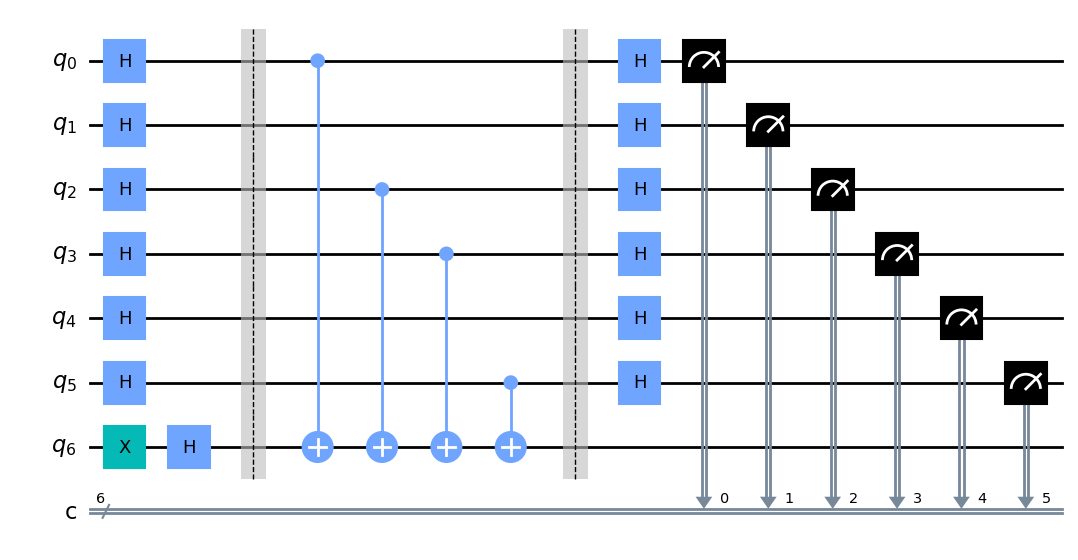

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

def demonstrate_quantum_advantage(secret_string="101101"):
    """Runs the Bernstein-Vazirani algorithm to find a secret string in ONE try."""
    print(f"The Secret String we are hiding is: {secret_string}")
    print(f"A classical computer would need {len(secret_string)} attempts to find this.")
    print("Running quantum circuit...\n")

    n = len(secret_string)
    # Create circuit: n input qubits, 1 ancilla qubit, n classical bits for output
    qc = QuantumCircuit(n + 1, n)

    # 1. Put the ancilla qubit (the last one) into the |1> state, then apply a Hadamard
    qc.x(n)
    qc.h(n)

    # 2. Apply Hadamard gates to all input qubits to create superposition
    qc.h(range(n))
    qc.barrier()

    # 3. Build the "Oracle" (The black box hiding our secret string)
    # Qiskit orders qubits in reverse (right-to-left), so we reverse the string
    reversed_string = secret_string[::-1]
    for q in range(n):
        if reversed_string[q] == '1':
            qc.cx(q, n) # Apply CNOT if the secret bit is 1

    qc.barrier()

    # 4. Apply final Hadamard gates to cause quantum interference
    qc.h(range(n))

    # 5. Measure the input qubits
    qc.measure(range(n), range(n))

    # 6. Run the simulation exactly ONE time
    simulator = AerSimulator()
    job = simulator.run(qc, shots=1)
    result = job.result()
    counts = result.get_counts(qc)

    # Output the result
    quantum_answer = list(counts.keys())[0]
    print("--- RESULTS ---")
    print(f"Quantum Computer guessed: {quantum_answer}")

    if quantum_answer == secret_string:
        print("SUCCESS! The Quantum Computer found the secret string in exactly 1 attempt!")

    # Draw the beautiful circuit layout
    display(qc.draw('mpl', style='clifford'))

# You can change the secret string to any combination of 1s and 0s!
demonstrate_quantum_advantage("101101")